# Autoencoder for Anomaly Detection

In this notebook we use an autoencoder as a simple **anomaly detection** method.

Idea:
- The autoencoder is trained only on the digits **1 to 9**.
- The digit **0** is deliberately left out during training.
- On the test data we compute the reconstruction loss for each image.
- If the idea works, the unseen `0` digits should be reconstructed worse on average and therefore get a higher reconstruction loss.


In [1]:
# Importing tensorflow
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
print('Done')


Done


## Load MNIST

This time we also need the labels, because we filter the training data and later compare the reconstruction losses for `0` and `not 0`.


In [2]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# The fully connected autoencoder expects vectors with 784 values.
x_train = x_train.reshape((len(x_train), -1))
x_test = x_test.reshape((len(x_test), -1))

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(60000, 784) (60000,)
(10000, 784) (10000,)


## Remove Zeros from Training

The digit `0` is our artificial anomaly. Therefore, we remove all `0` digits from the training data.


In [3]:
normal_train_mask = y_train != 0

x_train_normal = x_train[normal_train_mask]
y_train_normal = y_train[normal_train_mask]

print('Training images before filtering:', len(x_train))
print('Training images after filtering:', len(x_train_normal))
print('Number of zeros in filtered training data:', np.sum(y_train_normal == 0))


Training images before filtering: 60000
Training images after filtering: 54077
Number of zeros in filtered training data: 0


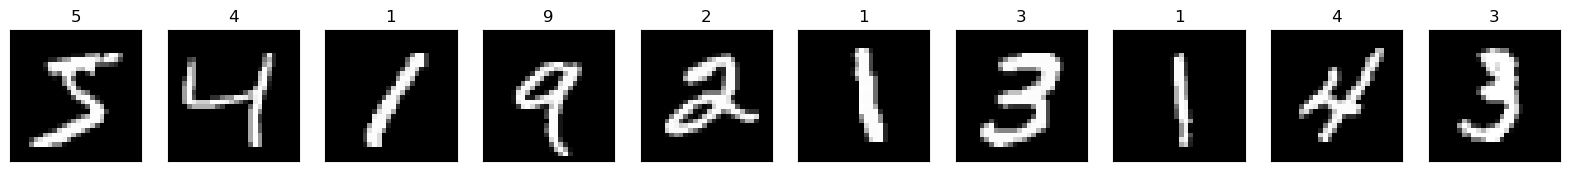

In [4]:
# Show a few training examples. There should be no zeros here.
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_train_normal[i].reshape(28, 28), cmap='gray')
    plt.title(str(y_train_normal[i]))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## Creating a Fully Connected Autoencoder

We use the simplest possible autoencoder structure:

- input: `784` values for one `28 x 28` image
- bottleneck: `32` values
- output: `784` reconstructed pixel values

The bottleneck forces the model to learn a compressed representation of digits `1` to `9`.


In [5]:
encoding_dim = 10  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder')(input_img)
decoded = layers.Dense(784, activation='sigmoid', name='decoder')(encoded)

autoencoder = keras.Model(input_img, decoded, name='Autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Dense)                      │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Dense)                      │ (None, 784)                 │           8,624 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,474 (64.35 KB)

 Trainable params: 16,474 (64.35 KB)

 Non-trainable params: 0 (0.00 B)

## Train only on Normal Data

The autoencoder learns to reconstruct only the digits `1` to `9`. The validation data also excludes `0`, so the validation loss matches the training task.


In [6]:
normal_test_mask = y_test != 0
x_test_normal = x_test[normal_test_mask]
y_test_normal = y_test[normal_test_mask]

# Training time should be less than a minute on many machines.
history = autoencoder.fit(
    x_train_normal, x_train_normal,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_normal, x_test_normal)
)


Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0874 - val_loss: 0.0592
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0524 - val_loss: 0.0460
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0427 - val_loss: 0.0394
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0383 - val_loss: 0.0364
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0359 - val_loss: 0.0346
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0344 - val_loss: 0.0335
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0335 - val_loss: 0.0328
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0329 - val_loss: 0.0322
Epoch 9/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0324 - val_loss: 0.0318
Epoch 10/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0320 - val_loss: 0.0314
Epoch 11/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0316 - val_loss: 0.0310
Epoch 12/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

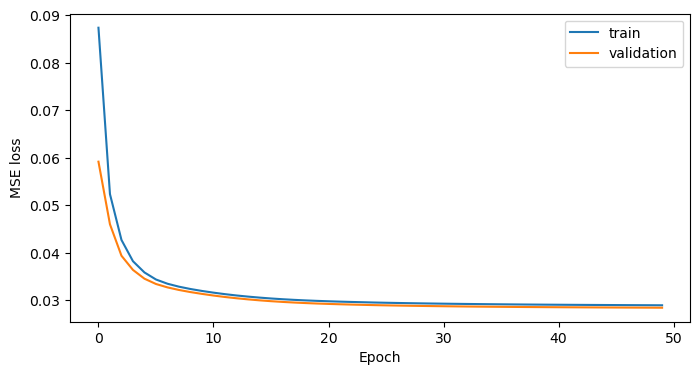

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.show()


## Reconstruction Loss as Anomaly Score

Now we reconstruct all test images, including the `0` digits. The anomaly score is the mean squared reconstruction error per image.


In [8]:
decoded_test = autoencoder.predict(x_test)

reconstruction_loss = np.mean(np.square(x_test - decoded_test), axis=1)
is_zero = y_test == 0

loss_zero = reconstruction_loss[is_zero]
loss_not_zero = reconstruction_loss[~is_zero]

print('Mean reconstruction loss for zeros:     ', loss_zero.mean())
print('Mean reconstruction loss for non-zeros: ', loss_not_zero.mean())
print('Median reconstruction loss for zeros:   ', np.median(loss_zero))
print('Median reconstruction loss for non-zeros:', np.median(loss_not_zero))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step
Mean reconstruction loss for zeros:      0.055838183
Mean reconstruction loss for non-zeros:  0.028474284
Median reconstruction loss for zeros:    0.053196535
Median reconstruction loss for non-zeros: 0.027429752


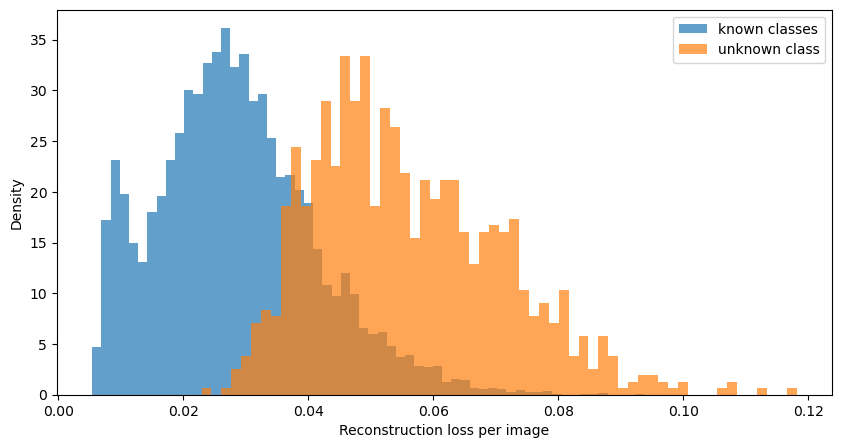

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(loss_not_zero, bins=60, alpha=0.7, label='known classes', density=True)
plt.hist(loss_zero, bins=60, alpha=0.7, label='unknown class', density=True)
plt.xlabel('Reconstruction loss per image')
plt.ylabel('Density')
plt.legend()
plt.show()


C:\Users\herrler\AppData\Local\Temp\ipykernel_31504\2212682556.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([loss_not_zero, loss_zero], labels=['not 0', '0'], showfliers=False)


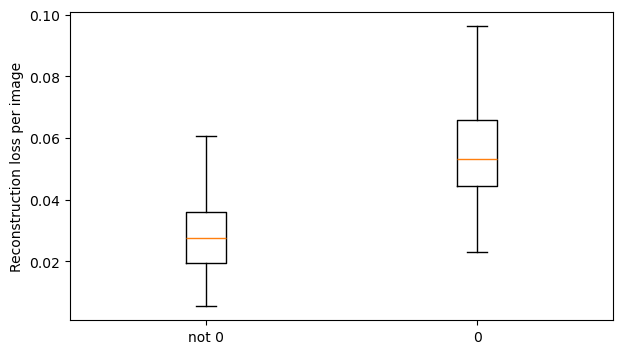

In [10]:
plt.figure(figsize=(7, 4))
plt.boxplot([loss_not_zero, loss_zero], labels=['not 0', '0'], showfliers=False)
plt.ylabel('Reconstruction loss per image')
plt.show()


## A Simple Threshold

In practice, we would choose a threshold on normal validation data. Here we use the 95th percentile of the normal test images as a simple example. Everything above this threshold is marked as an anomaly.


In [11]:
threshold = np.quantile(loss_not_zero, 0.95)
predicted_anomaly = reconstruction_loss > threshold

true_anomaly = is_zero

true_positive_rate = np.mean(predicted_anomaly[true_anomaly])
false_positive_rate = np.mean(predicted_anomaly[~true_anomaly])

print('Threshold:', threshold)
print('Detected zeros:', true_positive_rate)
print('False alarms on non-zeros:', false_positive_rate)


Threshold: 0.051446907
Detected zeros: 0.5540816326530612
False alarms on non-zeros: 0.05


## Inspect Reconstructions

The top row shows original images, the bottom row shows their reconstructions. First we inspect some `0` digits, then some normal digits with low reconstruction loss.


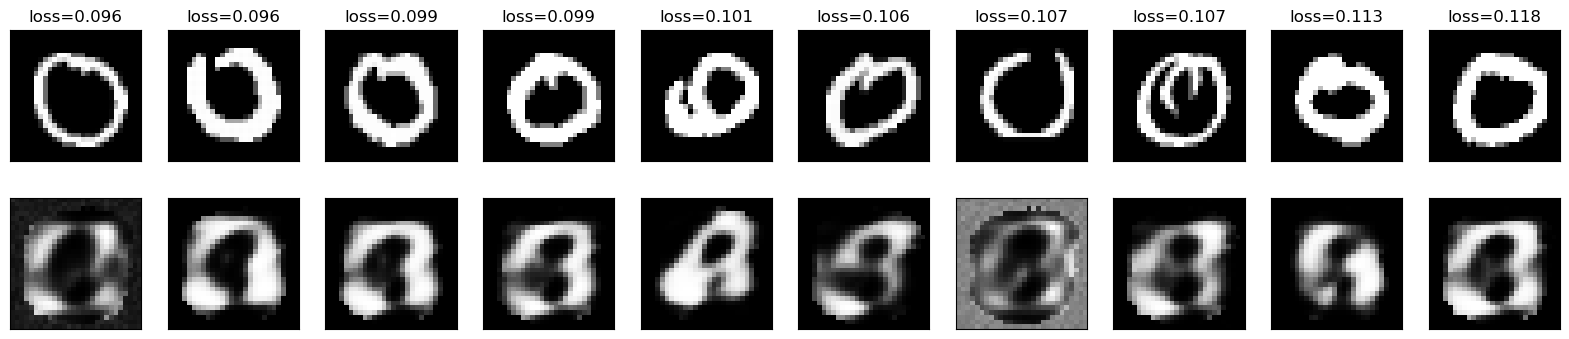

In [12]:
zero_indices = np.where(is_zero)[0]
# Show the zero examples with the highest reconstruction loss.
zero_indices = zero_indices[np.argsort(reconstruction_loss[zero_indices])[-10:]]

plt.figure(figsize=(20, 4))
for i, idx in enumerate(zero_indices):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'loss={reconstruction_loss[idx]:.3f}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_test[idx].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


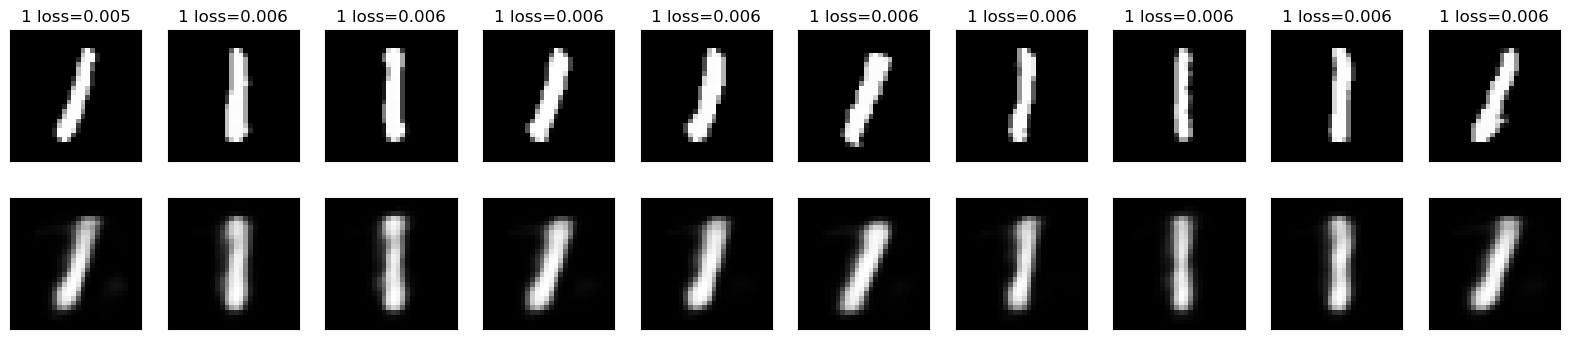

In [13]:
normal_indices = np.where(~is_zero)[0]
# Show normal examples with low reconstruction loss.
normal_indices = normal_indices[np.argsort(reconstruction_loss[normal_indices])[:10]]

plt.figure(figsize=(20, 4))
for i, idx in enumerate(normal_indices):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'{y_test[idx]} loss={reconstruction_loss[idx]:.3f}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_test[idx].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## Interpretation

If the autoencoder reconstructs the `0` digits worse, the loss distribution for `0` should be shifted to the right. The effect will not be perfect, because `0` digits are visually simple and an autoencoder can sometimes reconstruct unseen patterns reasonably well. Still, the notebook demonstrates the basic principle: **reconstruction loss can be used as an anomaly score**.
